# Backtesting with realistic slippage

**Use case: [Improve your backtest](https://aperiodic.io/use-cases/improve-your-backtest)**

A price-only backtest quietly assumes you can trade at the mid-price for free.
Real fills pay the half-spread, move the book, and miss when liquidity thins out.
This notebook builds a transaction-cost model from Aperiodic's **L1 price**,
**impact**, and **slippage** metrics, validates it against *measured* slippage,
and then shows how three different cost assumptions reshape the same simple
momentum backtest.

We study **Binance BTC perpetuals** (`perpetual-BTC-USDT:USDT`) at **5-minute**
resolution over **May 2025**, the window served by the shared `DEMO-KEY` preview
slice.

> **One month is an illustration, not evidence.** Every Sharpe ratio, return,
> and drawdown below comes from a single month of 5-minute data. Treat them as a
> worked example of *how costs change a backtest*, never as proof of a durable
> strategy.

**Background reading**
- Aperiodic trade metrics: https://aperiodic.io/metrics/trades
- Bid-ask spread & slippage: https://www.binance.com/en/academy/articles/bid-ask-spread-and-slippage-explained

## 1. Why mid-price fills overstate PnL

Three costs separate a paper fill from a real one:

- **Half-spread.** A market order to buy lifts the ask; a sell hits the bid. You
  immediately give up roughly half the quoted spread versus the mid-price.
- **Market impact.** Larger orders walk the book and move the price against
  themselves. Impact grows with order size and shrinks with available depth.
- **Opportunity cost / missed fills.** Passive orders avoid the spread but are
  not always filled, especially when the market runs away from the quote.

A backtest that fills at the mid-price for free captures none of this and will
systematically overstate performance — most of all for high-turnover signals.
The schematic below contrasts a naive mid fill with a cost-aware fill.

In [1]:
from __future__ import annotations

import os
from datetime import date

import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from aperiodic import get_metrics, get_ohlcv

sns.set_theme(style="whitegrid", context="talk", palette="deep")
pd.options.display.float_format = "{:,.4f}".format
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["figure.dpi"] = 140
plt.rcParams["savefig.dpi"] = 140
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

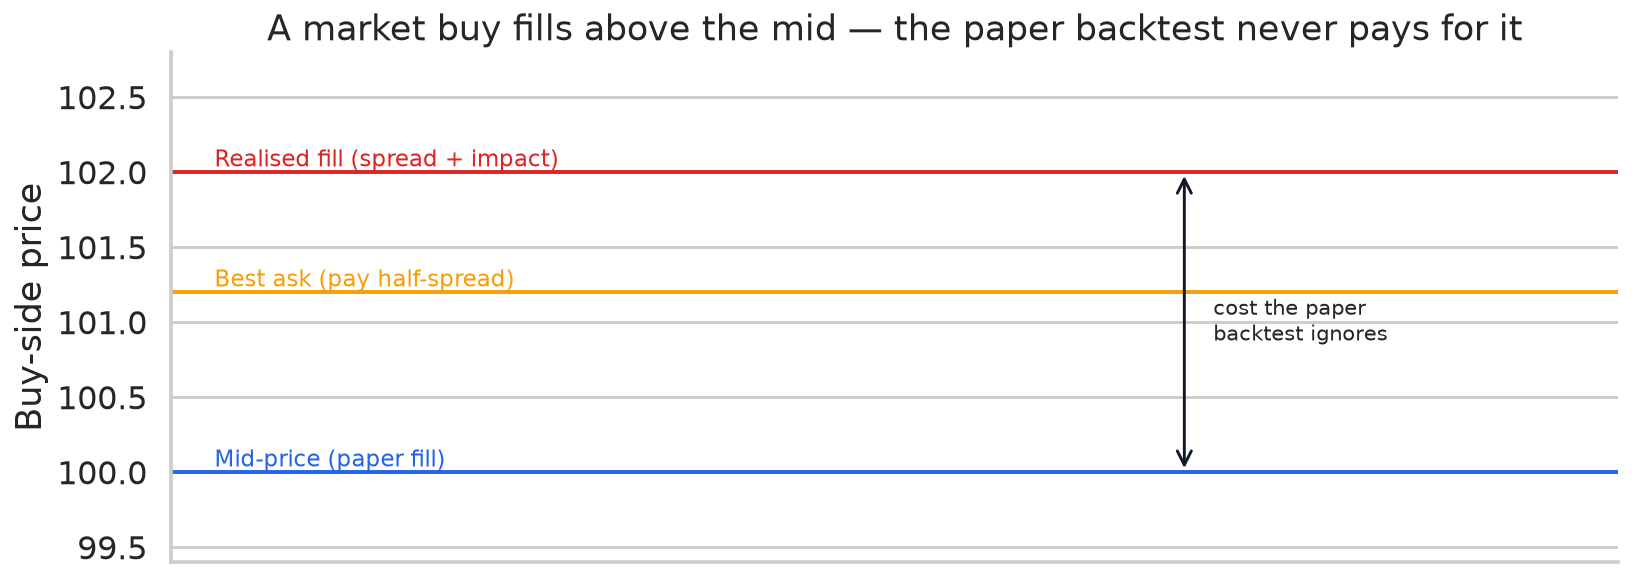

In [2]:
# Schematic only — no market data. A buy market order pays the ask (mid + half
# spread + impact); a paper backtest assumes the mid.
fig, ax = plt.subplots(figsize=(12, 4.5))
mid = 100.0
half_spread = 1.2
impact = 0.8
levels = {
    "Mid-price (paper fill)": (mid, "#2563eb"),
    "Best ask (pay half-spread)": (mid + half_spread, "#f59e0b"),
    "Realised fill (spread + impact)": (mid + half_spread + impact, "#dc2626"),
}
for i, (label, (level, color)) in enumerate(levels.items()):
    ax.axhline(level, color=color, linewidth=2)
    ax.text(0.02, level, f"  {label}", va="bottom", ha="left", color=color, fontsize=12)
ax.annotate(
    "",
    xy=(0.7, mid + half_spread + impact),
    xytext=(0.7, mid),
    arrowprops={"arrowstyle": "<->", "color": "#111827", "linewidth": 1.5},
)
ax.text(
    0.72,
    mid + (half_spread + impact) / 2,
    "cost the paper\nbacktest ignores",
    va="center",
    ha="left",
    fontsize=11,
)
ax.set_xlim(0, 1)
ax.set_ylim(mid - 0.6, mid + half_spread + impact + 0.8)
ax.set_xticks([])
ax.set_ylabel("Buy-side price")
ax.set_title("A market buy fills above the mid — the paper backtest never pays for it")
plt.tight_layout()

## 2. Configuration

Uppercase constants keep the public, non-sensitive parameters in one place. The
API key resolves in the order **inline value → `APERIODIC_API_KEY` → `DEMO-KEY`**.
With no key supplied, the notebook runs end-to-end on the `DEMO-KEY` preview
slice; supply your own key (inline or via the environment) to widen the window
against the standard endpoint.

In [3]:
EXCHANGE = "binance-futures"
SYMBOL = "perpetual-BTC-USDT:USDT"
INTERVAL = "5m"
START_DATE = date(2025, 5, 1)
END_DATE = date(2025, 5, 31)
TIMESTAMP = "exchange"  # exchange-reported time
START_TS = pd.Timestamp(START_DATE)
END_TS = pd.Timestamp(END_DATE) + pd.Timedelta(days=1)

# Order sizes (USD notional) used for the expected-cost curves.
ORDER_NOTIONALS = [10_000, 50_000, 100_000]
# One-way flat cost assumption, in basis points, for the naive "flat cost" backtest.
FLAT_COST_BPS = 5.0
# Reference order size (USD notional) priced by the dynamic-cost backtest.
BACKTEST_NOTIONAL = 50_000
# Lookback (bars) for the transparent toy momentum signal; 12 bars = 1 hour.
MOMENTUM_LOOKBACK = 12

API_KEY = "..."  # Set your key here, or via the APERIODIC_API_KEY env var
if API_KEY == "...":
    API_KEY = os.environ.get("APERIODIC_API_KEY", "DEMO-KEY")

# Only the shared "DEMO-KEY" runs against the preview endpoint. Provide your own
# key (above or via APERIODIC_API_KEY) to use the standard endpoint.
USE_PREVIEW = API_KEY == "DEMO-KEY"

print(f"Exchange / symbol : {EXCHANGE} / {SYMBOL}")
print(f"Interval / window : {INTERVAL} | {START_DATE} → {END_DATE}")
print(f"Order notionals   : {ORDER_NOTIONALS}")
print(f"Mode              : {'preview (DEMO-KEY)' if USE_PREVIEW else 'standard endpoint'}")

Exchange / symbol : binance-futures / perpetual-BTC-USDT:USDT
Interval / window : 5m | 2025-05-01 → 2025-05-31
Order notionals   : [10000, 50000, 100000]
Mode              : standard endpoint


## Helper functions

`clip_window` and `format_time_axis` match the introductory notebooks;
`run_position_backtest` is the same transaction-cost-aware backtest used in
`most-predictive.py` and `alpha-discovery.py` (5-minute annualisation);
`expected_cost_bps` is the local, unit-documented cost model built in this
notebook; and `audit_columns` prints the fetched schema and fails loudly if a
required field is absent.

In [4]:
def clip_window(df: pd.DataFrame) -> pd.DataFrame:
    """Normalise the `time` column and clip to the analysis window."""
    out = df.copy()
    out["time"] = pd.to_datetime(out["time"])
    out = out.loc[(out["time"] >= START_TS) & (out["time"] < END_TS)]
    return out.sort_values("time").reset_index(drop=True)


def format_time_axis(ax):
    locator = mdates.AutoDateLocator(minticks=6, maxticks=10)
    formatter = mdates.ConciseDateFormatter(locator)
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(formatter)


def audit_columns(frames: dict[str, tuple[pd.DataFrame, list[str]]]) -> None:
    """Print a compact schema report; raise (listing the real columns) if any
    required field is missing so one run surfaces the true schema."""
    lines, problems = [], []
    for name, (frame, required) in frames.items():
        cols = sorted(map(str, frame.columns))
        missing = [c for c in required if c not in frame.columns]
        lines.append(f"- {name:<10} {len(frame):>5} rows | columns={cols}")
        if missing:
            problems.append(f"{name} missing {missing}")
    report = "Fetched schema:\n" + "\n".join(lines)
    print(report)
    if problems:
        raise KeyError("; ".join(problems) + "\n" + report)


def run_position_backtest(
    timestamps: pd.Series,
    position: np.ndarray,
    forward_return: np.ndarray,
    cost_bps_one_way: float | np.ndarray = 0.0,
) -> tuple[pd.DataFrame, dict]:
    """Vectorised long/short backtest. `cost_bps_one_way` may be a scalar or a
    per-bar array (used for the dynamic, market-state-dependent cost model).
    Annualisation assumes 5-minute bars (288 per day)."""
    position = np.asarray(position, dtype=np.float64)
    forward_return = np.asarray(forward_return, dtype=np.float64)

    gross_pnl = position * forward_return
    turnover = np.abs(np.diff(position, prepend=0.0))
    cost = turnover * np.asarray(cost_bps_one_way, dtype=np.float64) / 1e4
    net_pnl = gross_pnl - cost
    equity = np.cumprod(1.0 + net_pnl)

    if equity.size == 0:
        bt_frame = pd.DataFrame({"timestamp": timestamps.to_numpy(), "equity_curve": equity})
        return bt_frame, {"annualized_sharpe": 0.0, "net_return_pct": 0.0, "max_drawdown_pct": 0.0}

    running_max = np.maximum.accumulate(equity)
    drawdowns = (equity - running_max) / running_max
    max_drawdown_pct = float(np.min(drawdowns)) * 100.0

    bars_per_year = 288 * 365
    mean_ret = float(np.mean(net_pnl))
    std_ret = float(np.std(net_pnl, ddof=1)) if len(net_pnl) > 1 else 1.0
    annualized_sharpe = (mean_ret / std_ret) * np.sqrt(bars_per_year) if std_ret > 0 else 0.0
    net_return_pct = float((equity[-1] / equity[0] - 1.0) * 100.0)

    bt_frame = pd.DataFrame({"timestamp": timestamps.to_numpy(), "equity_curve": equity})
    bt_summary = {
        "annualized_sharpe": float(annualized_sharpe),
        "net_return_pct": net_return_pct,
        "max_drawdown_pct": max_drawdown_pct,
    }
    return bt_frame, bt_summary


def expected_cost_bps(
    half_spread_bps: np.ndarray | pd.Series,
    impact_coef_bps_per_usd: np.ndarray | pd.Series,
    order_notional: float,
) -> np.ndarray:
    """One-way expected execution cost, in basis points, for a market order of
    `order_notional` USD.

        expected_cost_bps = half_spread_bps + impact_coef_bps_per_usd * order_notional

    Units: `half_spread_bps` is basis points of the mid; `impact_coef_bps_per_usd`
    is basis points of slippage per 1 USD of notional (so the product with a USD
    notional is again basis points). Inputs are used as-is — no clipping of
    negative or missing values — so calibration bias stays visible downstream.
    """
    half_spread_bps = np.asarray(half_spread_bps, dtype=np.float64)
    impact_coef_bps_per_usd = np.asarray(impact_coef_bps_per_usd, dtype=np.float64)
    return half_spread_bps + impact_coef_bps_per_usd * float(order_notional)

## 3. Fetch and align data

Four requests share the same common arguments (`api_key`, `preview`,
`timestamp`, `interval`, `exchange`, `symbol`, `start_date`, `end_date`,
`output="pandas"`, `show_progress=False`). We fetch price, top-of-book L1
prices, market-impact metrics, and *measured* slippage, then clip each frame to
the analysis window and join on `time`.

In [5]:
COMMON = dict(
    api_key=API_KEY,
    preview=USE_PREVIEW,
    timestamp=TIMESTAMP,
    interval=INTERVAL,
    exchange=EXCHANGE,
    symbol=SYMBOL,
    start_date=START_DATE,
    end_date=END_DATE,
    output="pandas",
    show_progress=False,
)

ohlcv = clip_window(get_ohlcv(**COMMON))
l1_price = clip_window(get_metrics(metric="l1_price", **COMMON))
impact = clip_window(get_metrics(metric="impact", **COMMON))
slippage = clip_window(get_metrics(metric="slippage", **COMMON))

audit_columns(
    {
        "ohlcv": (ohlcv, ["time", "close"]),
        "l1_price": (l1_price, ["time", "bid_price", "ask_price", "midprice", "weighted_midprice"]),
        "impact": (impact, ["time", "amihud_like", "kyle_like_lambda", "impact_per_notional"]),
        "slippage": (
            slippage,
            ["time", "slippage_bps_mean", "slippage_bps_std", "slippage_bps_p95", "slippage_bps_vwap"],
        ),
    }
)

Fetched schema:
- ohlcv       8928 rows | columns=['close', 'high', 'low', 'open', 'time', 'volume', 'volume_notional']
- l1_price    8928 rows | columns=['ask_amount', 'ask_price', 'ask_price_twap', 'ask_price_vwap', 'avg_update_interval', 'bid_amount', 'bid_price', 'bid_price_twap', 'bid_price_vwap', 'midprice', 'quote_update_frequency', 'time', 'weighted_midprice']
- impact      8928 rows | columns=['amihud_like', 'directional_impact_asymmetry', 'impact_per_notional', 'kyle_like_lambda', 'large_trade_reversal', 'time']
- slippage    8928 rows | columns=['slippage_bps_buy_mean', 'slippage_bps_buy_sell_ratio', 'slippage_bps_mean', 'slippage_bps_median', 'slippage_bps_p95', 'slippage_bps_sell_buy_ratio', 'slippage_bps_sell_mean', 'slippage_bps_std', 'slippage_bps_vwap', 'slippage_mean', 'time']


In [6]:
# Join on `time` (inner) so every row has price, L1, impact and slippage. Derive
# spread and half-spread in basis points from the quoted bid/ask.
df = (
    ohlcv[["time", "close"]]
    .merge(l1_price[["time", "bid_price", "ask_price", "midprice", "weighted_midprice"]], on="time", how="inner")
    .merge(impact[["time", "amihud_like", "kyle_like_lambda", "impact_per_notional"]], on="time", how="inner")
    .merge(
        slippage[["time", "slippage_bps_mean", "slippage_bps_std", "slippage_bps_p95", "slippage_bps_vwap"]],
        on="time",
        how="inner",
    )
    .sort_values("time")
    .reset_index(drop=True)
)

df["spread_bps"] = (df["ask_price"] - df["bid_price"]) / df["midprice"] * 1e4
df["half_spread_bps"] = 0.5 * df["spread_bps"]
df["ret"] = df["close"].pct_change()
df["realized_vol_1h_bps"] = df["ret"].rolling(12).std() * np.sqrt(12) * 1e4
df["hour"] = df["time"].dt.hour

coverage = pd.Series(
    {
        "Rows": len(df),
        "Start": df["time"].min(),
        "End": df["time"].max(),
        "Median spread (bps)": df["spread_bps"].median(),
        "Median half-spread (bps)": df["half_spread_bps"].median(),
        "Median measured slippage (bps)": df["slippage_bps_mean"].median(),
        "Median |impact_per_notional|": df["impact_per_notional"].abs().median(),
    }
)
coverage

Rows                                             8928
Start                             2025-05-01 00:00:00
End                               2025-05-31 23:55:00
Median spread (bps)                            0.0096
Median half-spread (bps)                       0.0048
Median measured slippage (bps)                 0.1419
Median |impact_per_notional|                   0.0000
dtype: object

In [7]:
df[
    [
        "time",
        "close",
        "spread_bps",
        "half_spread_bps",
        "impact_per_notional",
        "slippage_bps_mean",
        "slippage_bps_p95",
    ]
].head()

,time,close,spread_bps,half_spread_bps,impact_per_notional,slippage_bps_mean,slippage_bps_p95
0,2025-05-01 00:00:00,"94,190.3000",0.0106,0.0053,0.0000,0.1667,0.9668
1,2025-05-01 00:05:00,"94,257.0000",0.0106,0.0053,0.0000,0.2825,1.5282
2,2025-05-01 00:10:00,"94,223.6000",0.0106,0.0053,0.0000,0.1597,0.9440
3,2025-05-01 00:15:00,"94,187.9000",0.0106,0.0053,0.0000,0.1010,0.5307
4,2025-05-01 00:20:00,"94,218.8000",0.0106,0.0053,0.0000,0.0794,0.4886


## Chart 1 — Spread distribution by hour

Spread is the floor on execution cost. Plotting its full hourly distribution
(not just an average) shows how much intraday variation a fixed cost assumption
would paper over.

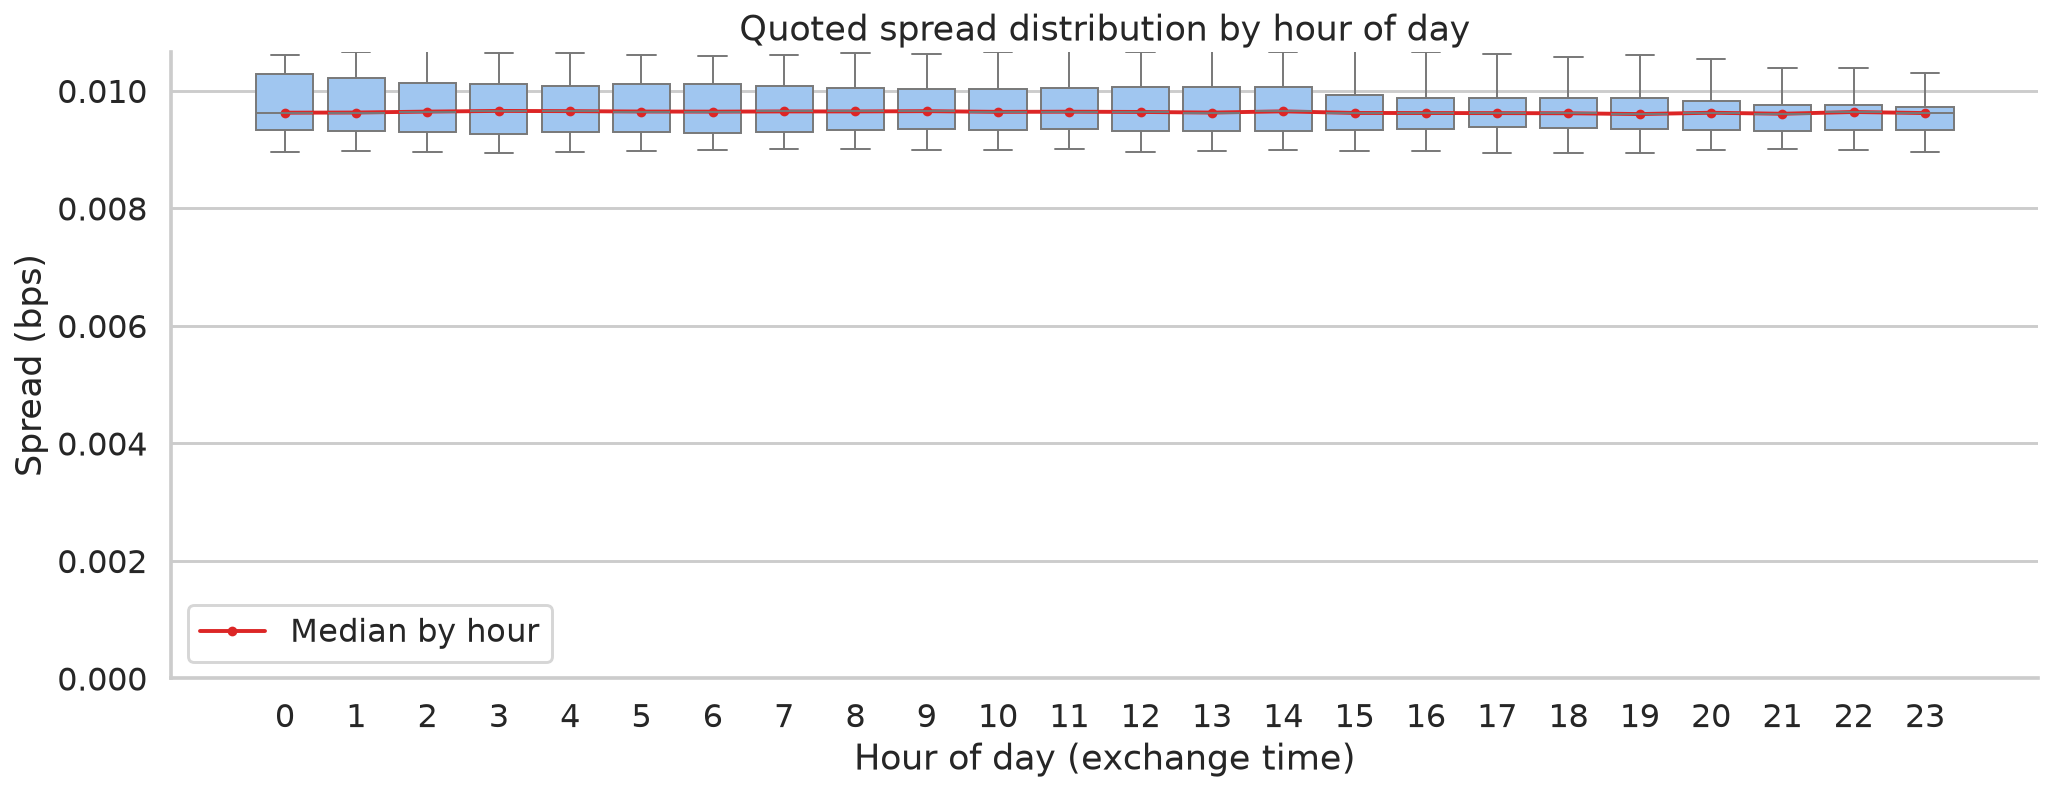

In [8]:
fig, ax = plt.subplots(figsize=(15, 6))
sns.boxplot(
    data=df,
    x="hour",
    y="spread_bps",
    color="#93c5fd",
    fliersize=0,
    ax=ax,
)
median_by_hour = df.groupby("hour")["spread_bps"].median()
ax.plot(
    median_by_hour.index,
    median_by_hour.to_numpy(),
    color="#dc2626",
    linewidth=2,
    marker="o",
    markersize=4,
    label="Median by hour",
)
ax.set_title("Quoted spread distribution by hour of day")
ax.set_xlabel("Hour of day (exchange time)")
ax.set_ylabel("Spread (bps)")
ax.set_ylim(0, df["spread_bps"].quantile(0.99))
ax.legend(frameon=True)
plt.tight_layout()

## Chart 2 — Spread, volatility and measured slippage

Execution cost co-moves with volatility. The top panel overlays the quoted
spread with rolling realised volatility; the bottom panel shows the distribution
of the four *measured* slippage statistics. Measured slippage is the catalogue
**ground truth** we will hold the cost model to.

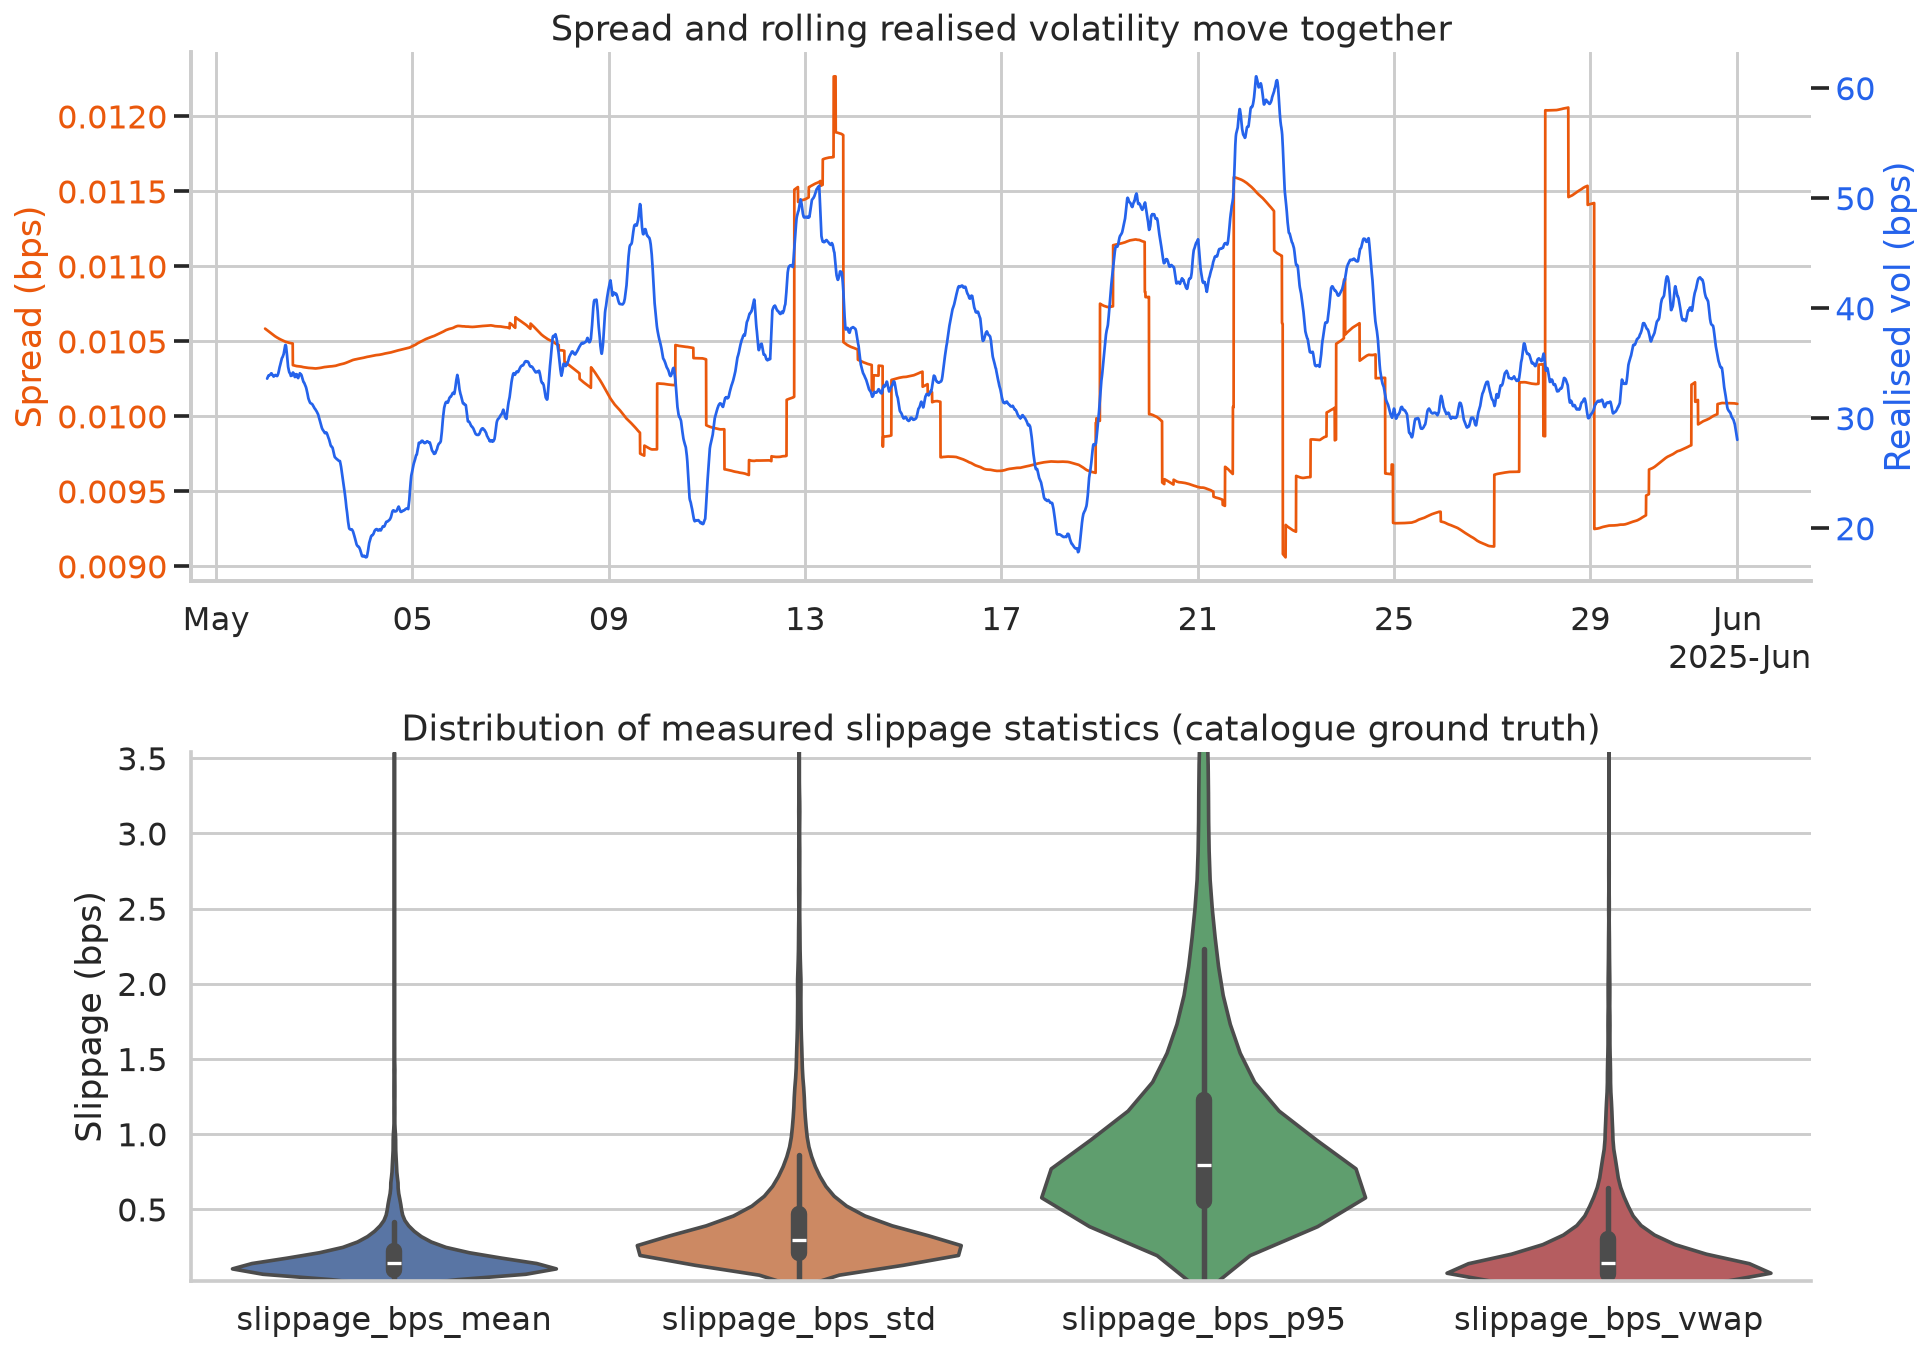

In [9]:
fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(14, 10))

ax_spread = ax_top
ax_spread.plot(df["time"], df["spread_bps"].rolling(288).mean(), color="#ea580c", linewidth=1.4, label="Spread (1d avg, bps)")
ax_spread.set_ylabel("Spread (bps)", color="#ea580c")
ax_spread.tick_params(axis="y", labelcolor="#ea580c")
ax_vol = ax_spread.twinx()
ax_vol.plot(df["time"], df["realized_vol_1h_bps"].rolling(288).mean(), color="#2563eb", linewidth=1.4, label="Realised vol (1d avg, bps)")
ax_vol.set_ylabel("Realised vol (bps)", color="#2563eb")
ax_vol.tick_params(axis="y", labelcolor="#2563eb")
ax_vol.grid(False)
ax_spread.set_title("Spread and rolling realised volatility move together")
format_time_axis(ax_spread)

slip_cols = ["slippage_bps_mean", "slippage_bps_std", "slippage_bps_p95", "slippage_bps_vwap"]
slip_long = df[slip_cols].melt(var_name="statistic", value_name="bps").dropna()
sns.violinplot(data=slip_long, x="statistic", y="bps", hue="statistic", legend=False, ax=ax_bot, palette="deep", cut=0)
ax_bot.set_title("Distribution of measured slippage statistics (catalogue ground truth)")
ax_bot.set_xlabel("")
ax_bot.set_ylabel("Slippage (bps)")
ax_bot.set_ylim(slip_long["bps"].quantile(0.01), slip_long["bps"].quantile(0.99))
plt.tight_layout()

## 6. Build and validate the cost model

The model combines the half-spread with an interval-specific impact coefficient
multiplied by order notional:

> `expected_cost_bps(order_notional) = half_spread_bps + impact_coef_bps_per_usd * order_notional`

We treat `impact_per_notional` as a **price fraction of impact per USD of
notional** and convert it to basis points (×10⁴). Because the catalogue's exact
units for this preview slice cannot be assumed, we do **not** tune the
coefficient to the target; instead we compare the modelled cost against measured
`slippage_bps_mean` and report the calibration gap, plus the impact coefficient
that measured slippage *implies* for reference.

Mean half-spread (bps): 0.0051
|   order_notional |   mean_model_cost_bps |   median_model_cost_bps |
|-----------------:|----------------------:|------------------------:|
|            10000 |             0.0468973 |               0.012775  |
|            50000 |             0.214144  |               0.0444429 |
|           100000 |             0.423202  |               0.0839596 |


Reference order notional (USD)               50,000.0000
Mean |modelled - measured| (bps)                  0.2963
Mean modelled cost (bps)                          0.2141
Mean measured slippage (bps)                      0.1948
Catalogue impact_coef (bps per $1M)               4.1812
Slippage-implied impact_coef (bps per $1M)        3.7953
dtype: float64

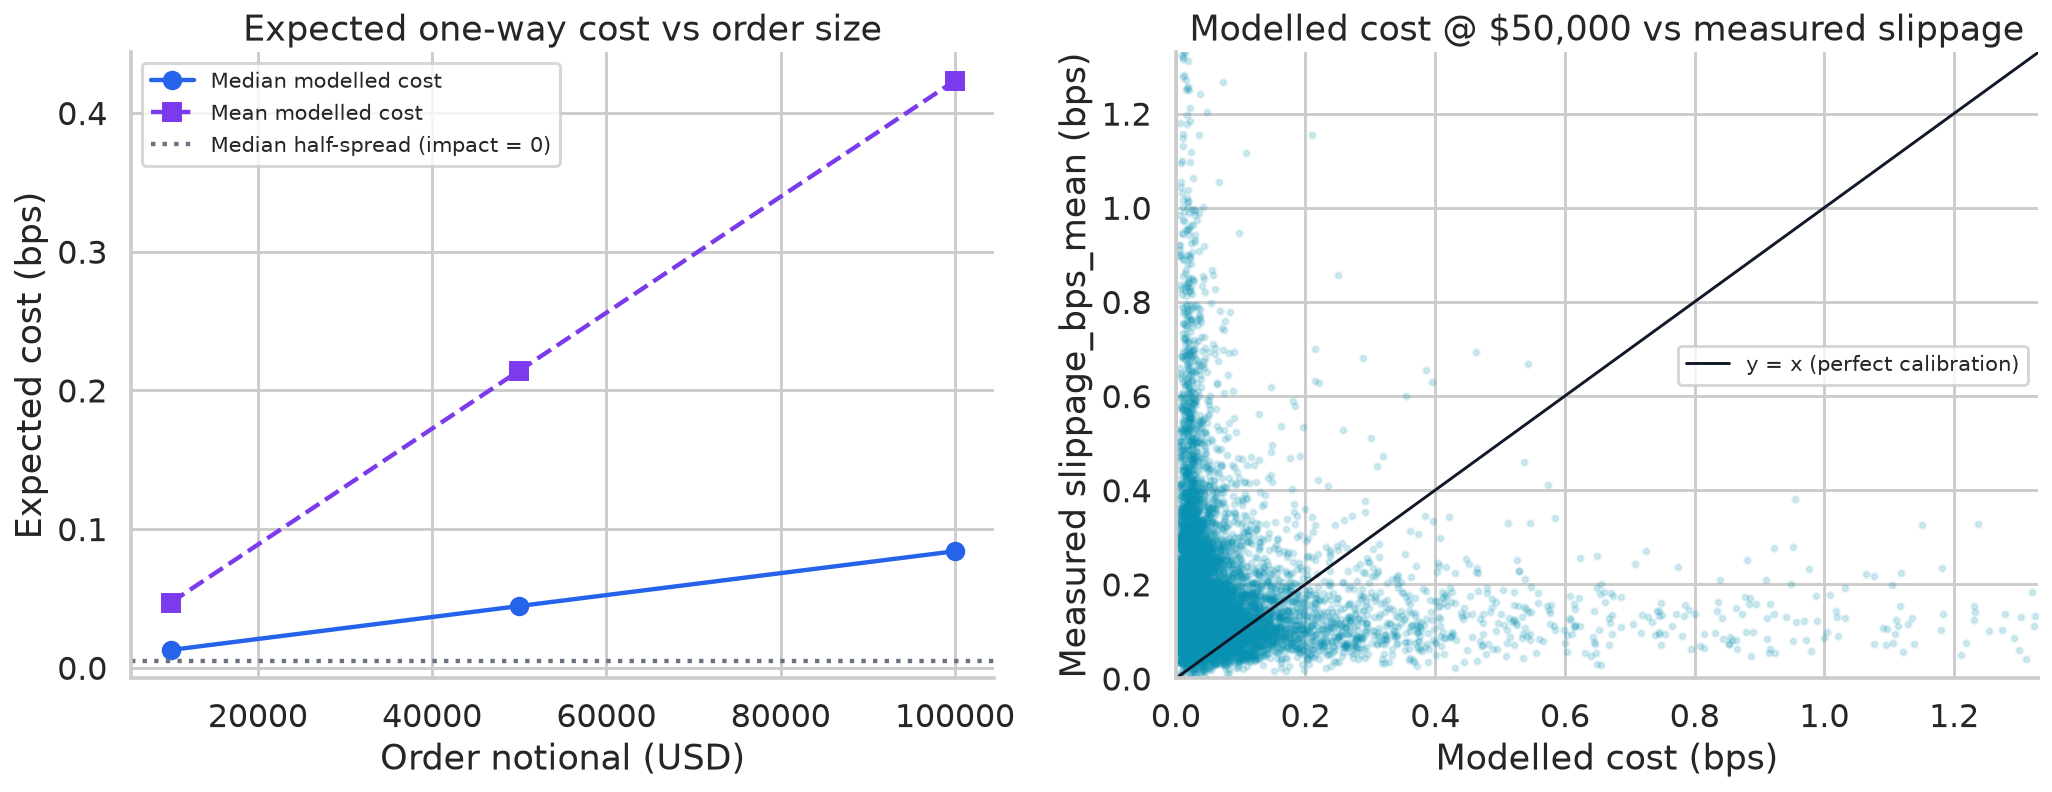

In [10]:
# Interval-specific impact coefficient, expressed in bps of slippage per 1 USD of
# notional. impact_per_notional is a price fraction per USD -> ×1e4 to bps.
df["impact_coef_bps_per_usd"] = df["impact_per_notional"].abs() * 1e4

for notional in ORDER_NOTIONALS:
    df[f"model_cost_bps_{notional}"] = expected_cost_bps(
        df["half_spread_bps"], df["impact_coef_bps_per_usd"], notional
    )

# Expected-cost curves: mean modelled cost across the month for each order size.
curve = pd.DataFrame(
    {
        "order_notional": ORDER_NOTIONALS,
        "mean_model_cost_bps": [df[f"model_cost_bps_{n}"].mean() for n in ORDER_NOTIONALS],
        "median_model_cost_bps": [df[f"model_cost_bps_{n}"].median() for n in ORDER_NOTIONALS],
    }
)
print("Mean half-spread (bps):", round(df["half_spread_bps"].mean(), 4))
print(curve.to_markdown(index=False))

fig, (ax_curve, ax_cal) = plt.subplots(1, 2, figsize=(15, 6))
ax_curve.plot(curve["order_notional"], curve["median_model_cost_bps"], marker="o", color="#2563eb", label="Median modelled cost")
ax_curve.plot(curve["order_notional"], curve["mean_model_cost_bps"], marker="s", color="#7c3aed", linestyle="--", label="Mean modelled cost")
ax_curve.axhline(df["half_spread_bps"].median(), color="#6b7280", linestyle=":", label="Median half-spread (impact = 0)")
ax_curve.set_title("Expected one-way cost vs order size")
ax_curve.set_xlabel("Order notional (USD)")
ax_curve.set_ylabel("Expected cost (bps)")
ax_curve.legend(frameon=True, fontsize=11)

# Calibration: modelled cost at the reference size vs measured slippage_bps_mean.
cal = df[["half_spread_bps", f"model_cost_bps_{BACKTEST_NOTIONAL}", "slippage_bps_mean"]].dropna()
ax_cal.scatter(cal[f"model_cost_bps_{BACKTEST_NOTIONAL}"], cal["slippage_bps_mean"], s=8, alpha=0.15, color="#0891b2")
lim = float(np.nanpercentile(pd.concat([cal[f"model_cost_bps_{BACKTEST_NOTIONAL}"], cal["slippage_bps_mean"]]), 99))
ax_cal.plot([0, lim], [0, lim], color="#111827", linewidth=1.5, label="y = x (perfect calibration)")
ax_cal.set_xlim(0, lim)
ax_cal.set_ylim(0, lim)
ax_cal.set_title(f"Modelled cost @ ${BACKTEST_NOTIONAL:,} vs measured slippage")
ax_cal.set_xlabel("Modelled cost (bps)")
ax_cal.set_ylabel("Measured slippage_bps_mean (bps)")
ax_cal.legend(frameon=True, fontsize=11)
plt.tight_layout()

# Calibration error and the impact coefficient measured slippage would imply.
model_at_ref = df[f"model_cost_bps_{BACKTEST_NOTIONAL}"]
calibration_error_bps = (model_at_ref - df["slippage_bps_mean"]).abs().mean()
implied_coef = ((df["slippage_bps_mean"] - df["half_spread_bps"]).clip(lower=0) / BACKTEST_NOTIONAL)
calibration = pd.Series(
    {
        "Reference order notional (USD)": BACKTEST_NOTIONAL,
        "Mean |modelled - measured| (bps)": calibration_error_bps,
        "Mean modelled cost (bps)": model_at_ref.mean(),
        "Mean measured slippage (bps)": df["slippage_bps_mean"].mean(),
        "Catalogue impact_coef (bps per $1M)": df["impact_coef_bps_per_usd"].mean() * 1e6,
        "Slippage-implied impact_coef (bps per $1M)": implied_coef.mean() * 1e6,
    }
)
calibration

The scatter and the reported gap describe how well the catalogue-derived cost
model tracks measured slippage in-sample. A systematic offset means the impact
scale (or the half-spread assumption) is biased for this order size; wide
dispersion means the point-in-time cost is noisier than any single coefficient
can capture. Neither is tuned away here — a deployable model would recalibrate
the coefficient against measured slippage for its own order size.

## Chart 3 — Cost assumptions change the backtest

A transparent toy momentum signal — the sign of the mean return over the last
`MOMENTUM_LOOKBACK` bars — is traded three ways with `run_position_backtest`:
**zero cost**, **flat `FLAT_COST_BPS`**, and the **modelled dynamic cost** at
`BACKTEST_NOTIONAL` (a per-bar cost array). The signal is identical across the
three; only the cost assumption differs.

| scenario                   |   annualized_sharpe |   net_return_pct |   max_drawdown_pct |
|:---------------------------|--------------------:|-----------------:|-------------------:|
| Zero cost (paper)          |            0.958229 |          2.47313 |           -6.00429 |
| Flat 5 bps                 |          -36.5351   |        -70.1696  |          -70.3461  |
| Modelled dynamic @ $50,000 |           -0.27949  |         -1.46414 |           -7.2003  |


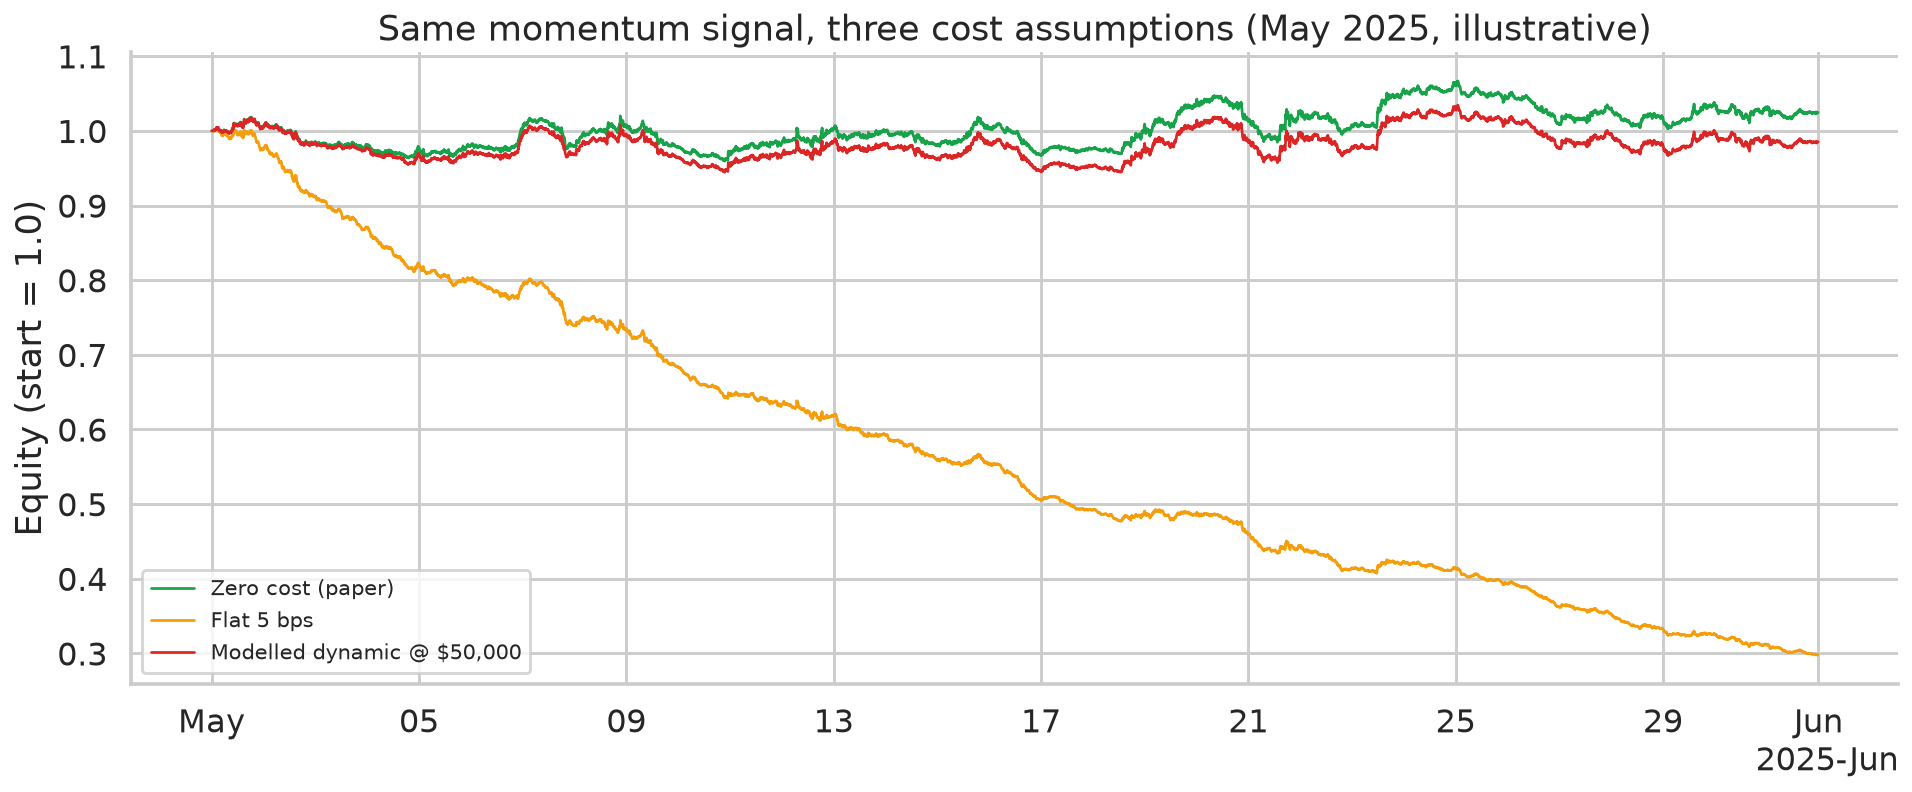

In [11]:
bt = df.dropna(subset=["ret", "half_spread_bps", "impact_coef_bps_per_usd"]).reset_index(drop=True)
momentum = bt["ret"].rolling(MOMENTUM_LOOKBACK).mean()
position = np.sign(momentum).fillna(0.0).to_numpy()          # info up to bar t only
forward_return = bt["close"].pct_change().shift(-1).to_numpy()  # return from t to t+1
dynamic_cost_bps = expected_cost_bps(
    bt["half_spread_bps"], bt["impact_coef_bps_per_usd"], BACKTEST_NOTIONAL
)

valid = np.isfinite(position) & np.isfinite(forward_return) & np.isfinite(dynamic_cost_bps)
ts = bt.loc[valid, "time"]
pos_v = np.nan_to_num(position[valid])
fret_v = np.nan_to_num(forward_return[valid])
dyn_v = np.asarray(dynamic_cost_bps)[valid]

scenarios = {
    "Zero cost (paper)": 0.0,
    f"Flat {FLAT_COST_BPS:g} bps": FLAT_COST_BPS,
    f"Modelled dynamic @ ${BACKTEST_NOTIONAL:,}": dyn_v,
}
colors = {"Zero cost (paper)": "#16a34a", f"Flat {FLAT_COST_BPS:g} bps": "#f59e0b", f"Modelled dynamic @ ${BACKTEST_NOTIONAL:,}": "#dc2626"}

fig, ax = plt.subplots(figsize=(14, 6))
rows = []
for label, cost in scenarios.items():
    frame, summ = run_position_backtest(ts, pos_v, fret_v, cost_bps_one_way=cost)
    ax.plot(frame["timestamp"], frame["equity_curve"], linewidth=1.4, color=colors[label], label=label)
    rows.append(
        {
            "scenario": label,
            "annualized_sharpe": summ["annualized_sharpe"],
            "net_return_pct": summ["net_return_pct"],
            "max_drawdown_pct": summ["max_drawdown_pct"],
        }
    )
ax.set_title("Same momentum signal, three cost assumptions (May 2025, illustrative)")
ax.set_ylabel("Equity (start = 1.0)")
ax.legend(frameon=True, fontsize=11)
format_time_axis(ax)
plt.tight_layout()

summary_table = pd.DataFrame(rows)
print(summary_table.to_markdown(index=False))

## Takeaways

- **Mid-price backtests flatter high-turnover signals most.** The gap between
  the zero-cost curve and the cost-aware curves above is pure execution drag the
  paper backtest ignored.
- **A flat cost is a blunt instrument.** Spread and impact vary by hour and with
  volatility (Charts 1–2), so a single number is too optimistic in stressed
  periods and too harsh in calm ones.
- **Measured slippage is the yardstick.** Section 6 holds the modelled cost to
  the catalogue's `slippage_bps_mean`; the reported gap is where a deployable
  model would recalibrate for its own order size.
- **One month proves nothing.** These Sharpe/return/drawdown figures are a
  worked example of how costs reshape a backtest, not evidence of an edge.

## Further reading
- [Improve your backtest](https://aperiodic.io/use-cases/improve-your-backtest)
- [Trade metrics](https://aperiodic.io/metrics/trades)
- Funding-aware follow-up: `notebooks/backtest-funding.py`
- Related notebooks: `notebooks/most-predictive.py`, `notebooks/alpha-discovery.py`